
GoogleNet (Inception V1) Model:
Epoch 1/20
422/422 [==============================] - 293s 681ms/step - loss: 0.9783 - accuracy: 0.6175 - val_loss: 0.1817 - val_accuracy: 0.9548
Epoch 2/20
422/422 [==============================] - 280s 663ms/step - loss: 0.1098 - accuracy: 0.9714 - val_loss: 0.0510 - val_accuracy: 0.9870
Epoch 3/20
422/422 [==============================] - 285s 676ms/step - loss: 0.0786 - accuracy: 0.9795 - val_loss: 0.0653 - val_accuracy: 0.9822
Epoch 4/20
422/422 [==============================] - 278s 660ms/step - loss: 0.0525 - accuracy: 0.9866 - val_loss: 0.0516 - val_accuracy: 0.9880
Epoch 5/20
422/422 [==============================] - 284s 672ms/step - loss: 0.0499 - accuracy: 0.9874 - val_loss: 0.0398 - val_accuracy: 0.9903
Epoch 6/20
422/422 [==============================] - 282s 668ms/step - loss: 0.0412 - accuracy: 0.9897 - val_loss: 0.0425 - val_accuracy: 0.9917
Epoch 7/20
422/422 [==============================] - 281s 665ms/step - loss: 0.0445 - accu

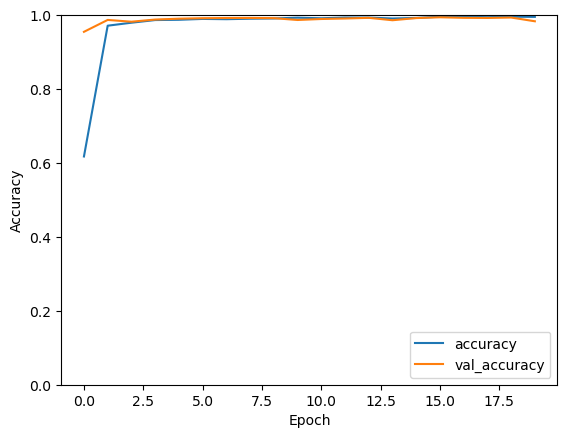

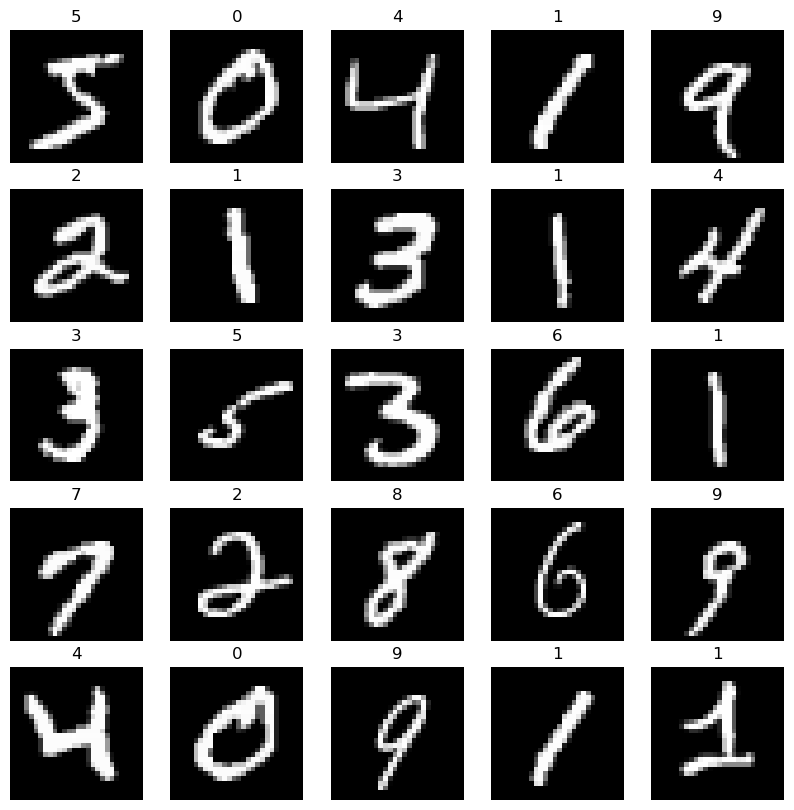

In [5]:
#GoogleNet model
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Layer, concatenate, GlobalAveragePooling2D
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# Preprocess data
x_train_preprocessed = x_train.astype('float32') / 255.0
x_test_preprocessed = x_test.astype('float32') / 255.0

# Define Inception module layer
class InceptionModule(Layer):
    def __init__(self, filters_1x1, filters_3x3_reduce, filters_3x3, filters_5x5_reduce, filters_5x5, filters_pool, **kwargs):
        super(InceptionModule, self).__init__(**kwargs)
        self.branch1x1 = Conv2D(filters_1x1, (1, 1), padding='same', activation='relu')
        
        self.branch3x3_reduce = Conv2D(filters_3x3_reduce, (1, 1), padding='same', activation='relu')
        self.branch3x3 = Conv2D(filters_3x3, (3, 3), padding='same', activation='relu')
        
        self.branch5x5_reduce = Conv2D(filters_5x5_reduce, (1, 1), padding='same', activation='relu')
        self.branch5x5 = Conv2D(filters_5x5, (5, 5), padding='same', activation='relu')
        
        self.branch_pool = MaxPooling2D((3, 3), strides=(1, 1), padding='same')
        self.branch_pool_conv = Conv2D(filters_pool, (1, 1), padding='same', activation='relu')

    def call(self, inputs):
        branch1x1 = self.branch1x1(inputs)
        
        branch3x3 = self.branch3x3_reduce(inputs)
        branch3x3 = self.branch3x3(branch3x3)
        
        branch5x5 = self.branch5x5_reduce(inputs)
        branch5x5 = self.branch5x5(branch5x5)
        
        branch_pool = self.branch_pool(inputs)
        branch_pool = self.branch_pool_conv(branch_pool)
        
        return concatenate([branch1x1, branch3x3, branch5x5, branch_pool], axis=-1)

# Define GoogleNet (Inception V1) model
def create_googlenet_model():
    model = Sequential()
    model.add(Conv2D(64, (7, 7), activation='relu', strides=(2, 2), padding='same', input_shape=(28, 28, 1)))
    model.add(MaxPooling2D((3, 3), strides=(2, 2), padding='same'))
    model.add(Conv2D(64, (1, 1), activation='relu', padding='same'))
    model.add(Conv2D(192, (3, 3), activation='relu', padding='same'))
    model.add(MaxPooling2D((3, 3), strides=(2, 2), padding='same'))

    # Inception modules
    model.add(InceptionModule(64, 96, 128, 16, 32, 32))  # 3a
    model.add(InceptionModule(128, 128, 192, 32, 96, 64))  # 3b
    model.add(MaxPooling2D((3, 3), strides=(2, 2), padding='same'))

    model.add(InceptionModule(192, 96, 208, 16, 48, 64))  # 4a
    model.add(InceptionModule(160, 112, 224, 24, 64, 64))  # 4b
    model.add(InceptionModule(128, 128, 256, 24, 64, 64))  # 4c
    model.add(InceptionModule(112, 144, 288, 32, 64, 64))  # 4d
    model.add(InceptionModule(256, 160, 320, 32, 128, 128))  # 4e
    model.add(MaxPooling2D((3, 3), strides=(2, 2), padding='same'))

    model.add(InceptionModule(256, 160, 320, 32, 128, 128))  # 5a
    model.add(InceptionModule(384, 192, 384, 48, 128, 128))  # 5b

    # Global average pooling
    model.add(GlobalAveragePooling2D())

    model.add(Dense(10, activation='softmax'))  # Output layer for 10 classes
    return model

# Compile and train model
def compile_and_train_model(model):
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    history = model.fit(x_train_preprocessed, y_train, epochs=20, batch_size=128, validation_split=0.1)
    return history

# Evaluate model
def evaluate_model(model):
    _, accuracy = model.evaluate(x_test_preprocessed, y_test)
    print("Test Accuracy:", accuracy)

# Plot training history
def plot_training_history(history):
    plt.plot(history.history['accuracy'], label='accuracy')
    plt.plot(history.history['val_accuracy'], label='val_accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.ylim([0, 1])
    plt.legend(loc='lower right')
    plt.show()

# Create and train GoogleNet model
print("\nGoogleNet (Inception V1) Model:")
googlenet_model = create_googlenet_model()
history = compile_and_train_model(googlenet_model)
evaluate_model(googlenet_model)

# Plot training history
plot_training_history(history)

# Plot a sample of images along with their labels
plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.imshow(x_train_preprocessed[i].squeeze(), cmap='gray')
    plt.title(np.argmax(y_train[i]))
    plt.axis('off')
plt.show()



VGG Model:
Epoch 1/30
422/422 [==============================] - 199s 471ms/step - loss: 0.1394 - accuracy: 0.9561 - val_loss: 0.0574 - val_accuracy: 0.9832
Epoch 2/30
422/422 [==============================] - 194s 459ms/step - loss: 0.0386 - accuracy: 0.9882 - val_loss: 0.0312 - val_accuracy: 0.9920
Epoch 3/30
422/422 [==============================] - 197s 467ms/step - loss: 0.0237 - accuracy: 0.9926 - val_loss: 0.0299 - val_accuracy: 0.9910
Epoch 4/30
422/422 [==============================] - 199s 472ms/step - loss: 0.0174 - accuracy: 0.9942 - val_loss: 0.0270 - val_accuracy: 0.9920
Epoch 5/30
422/422 [==============================] - 194s 460ms/step - loss: 0.0130 - accuracy: 0.9960 - val_loss: 0.0290 - val_accuracy: 0.9933
Epoch 6/30
422/422 [==============================] - 196s 465ms/step - loss: 0.0101 - accuracy: 0.9970 - val_loss: 0.0290 - val_accuracy: 0.9938
Epoch 7/30
422/422 [==============================] - 179s 425ms/step - loss: 0.0085 - accuracy: 0.9973 - val_lo

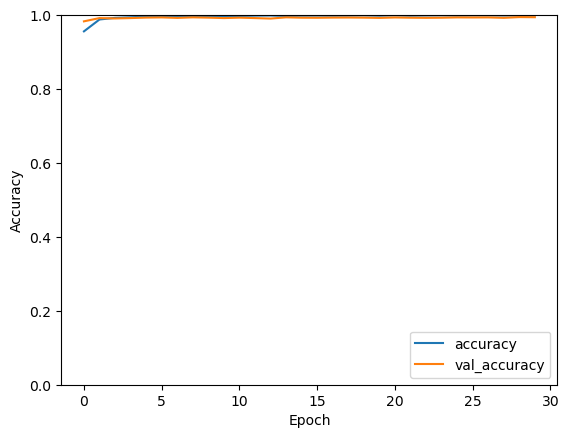

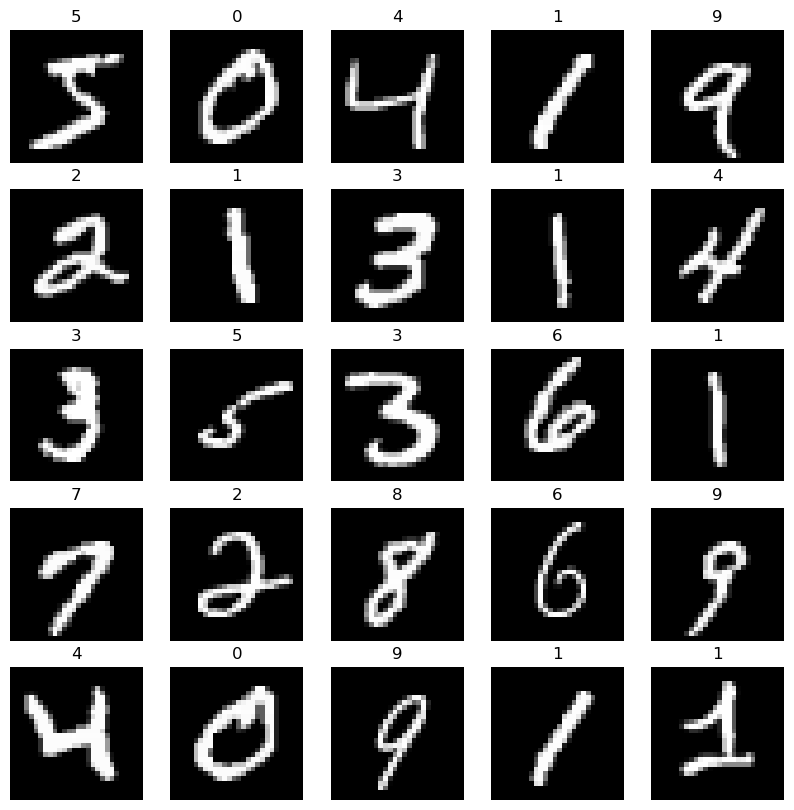

In [2]:
#VGG model 

import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# Preprocess data
x_train_preprocessed = x_train.astype('float32') / 255.0
x_test_preprocessed = x_test.astype('float32') / 255.0

# Define VGG model
def create_vgg_model():
    model = Sequential()
    model.add(Conv2D(64, (3, 3), activation='relu', padding='same', input_shape=(28, 28, 1)))
    model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(MaxPooling2D((2, 2)))
    model.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
    model.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
    model.add(MaxPooling2D((2, 2)))
    model.add(Flatten())
    model.add(Dense(256, activation='relu'))
    model.add(Dense(10, activation='softmax'))
    return model

# Compile and train model
def compile_and_train_model(model):
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    history = model.fit(x_train_preprocessed, y_train, epochs=30, batch_size=128, validation_split=0.1)
    return history

# Evaluate model
def evaluate_model(model):
    _, accuracy = model.evaluate(x_test_preprocessed, y_test)
    print("Test Accuracy:", accuracy)

# Plot training history
def plot_training_history(history):
    plt.plot(history.history['accuracy'], label='accuracy')
    plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.ylim([0, 1])
    plt.legend(loc='lower right')
    plt.show()

# Create and train VGG model
print("\nVGG Model:")
vgg_model = create_vgg_model()
history = compile_and_train_model(vgg_model)
evaluate_model(vgg_model)

# Plot training history
plot_training_history(history)

# Plot a sample of images along with their labels
plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.imshow(x_train_preprocessed[i].squeeze(), cmap='gray')
    plt.title(np.argmax(y_train[i]))
    plt.axis('off')
plt.show()



VGG Model for CIFAR-10:
Epoch 1/20
352/352 [==============================] - 298s 825ms/step - loss: 1.5096 - accuracy: 0.4536 - val_loss: 1.1628 - val_accuracy: 0.5980
Epoch 2/20
352/352 [==============================] - 307s 874ms/step - loss: 1.0050 - accuracy: 0.6458 - val_loss: 0.8569 - val_accuracy: 0.6994
Epoch 3/20
352/352 [==============================] - 304s 864ms/step - loss: 0.7853 - accuracy: 0.7234 - val_loss: 0.7844 - val_accuracy: 0.7280
Epoch 4/20
352/352 [==============================] - 199s 565ms/step - loss: 0.6325 - accuracy: 0.7792 - val_loss: 0.7395 - val_accuracy: 0.7498
Epoch 5/20
352/352 [==============================] - 187s 533ms/step - loss: 0.5122 - accuracy: 0.8226 - val_loss: 0.7198 - val_accuracy: 0.7608
Epoch 6/20
352/352 [==============================] - 185s 525ms/step - loss: 0.4011 - accuracy: 0.8585 - val_loss: 0.7023 - val_accuracy: 0.7662
Epoch 7/20
352/352 [==============================] - 190s 540ms/step - loss: 0.2922 - accuracy: 0.

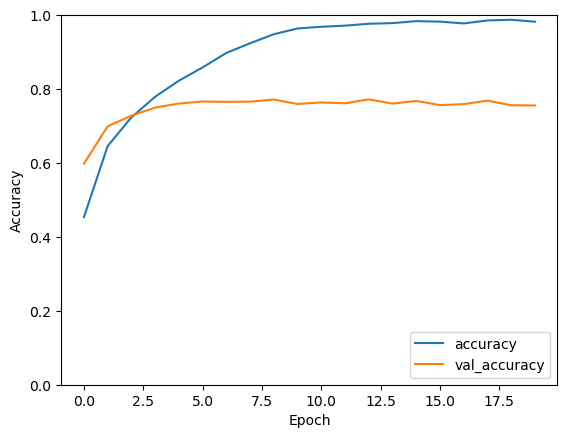

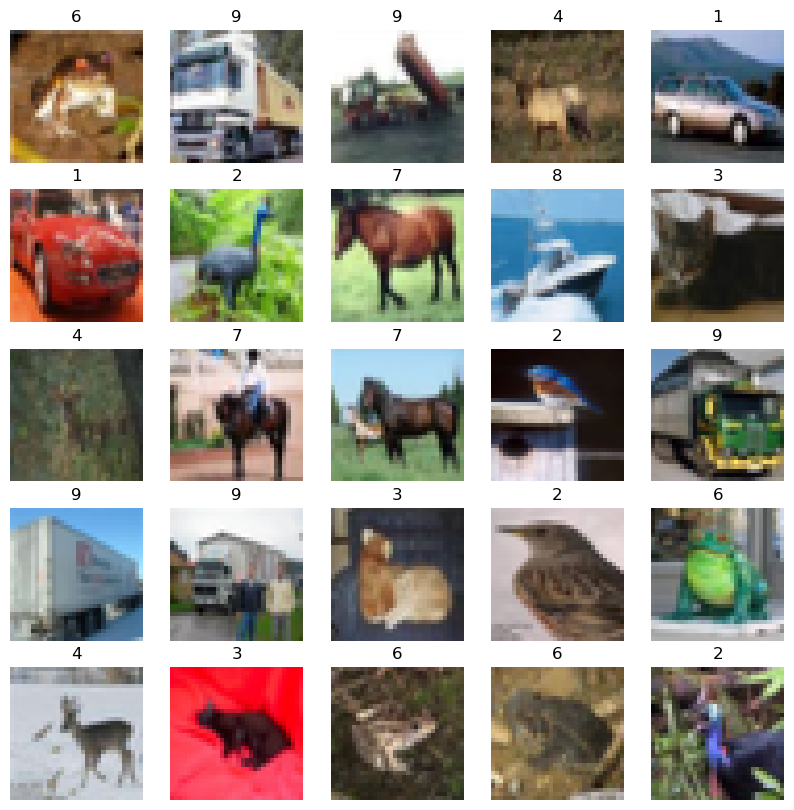

In [2]:
#VGG for CIFAR

import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

# Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# Preprocess data
x_train_preprocessed = x_train.astype('float32') / 255.0
x_test_preprocessed = x_test.astype('float32') / 255.0

# Define VGG model
def create_vgg_model():
    model = Sequential()
    model.add(Conv2D(64, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)))
    model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(MaxPooling2D((2, 2)))
    model.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
    model.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
    model.add(MaxPooling2D((2, 2)))
    model.add(Flatten())
    model.add(Dense(256, activation='relu'))
    model.add(Dense(10, activation='softmax'))  # Output layer for 10 classes
    return model

# Compile and train model
def compile_and_train_model(model):
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    history = model.fit(x_train_preprocessed, y_train, epochs=20, batch_size=128, validation_split=0.1)
    return history

# Evaluate model
def evaluate_model(model):
    _, accuracy = model.evaluate(x_test_preprocessed, y_test)
    print("Test Accuracy:", accuracy)

# Plot training history
def plot_training_history(history):
    plt.plot(history.history['accuracy'], label='accuracy')
    plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.ylim([0, 1])
    plt.legend(loc='lower right')
    plt.show()

# Create and train VGG model
print("\nVGG Model for CIFAR-10:")
vgg_model = create_vgg_model()
history = compile_and_train_model(vgg_model)
evaluate_model(vgg_model)

# Plot training history
plot_training_history(history)

# Plot a sample of images along with their labels
plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.imshow(x_train_preprocessed[i])
    plt.title(np.argmax(y_train[i]))
    plt.axis('off')
plt.show()


2024-05-08 11:58:18.479053: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-05-08 11:58:18.519598: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-05-08 11:58:18.519662: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-05-08 11:58:18.520973: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-05-08 11:58:18.527978: I tensorflow/core/platform/cpu_feature_guar

Num GPUs Available:  0


2024-05-08 11:58:20.380718: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2256] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...



GoogleNet (Inception V1) Model:
Epoch 1/20
352/352 [==============================] - 304s 841ms/step - loss: 2.3030 - accuracy: 0.1062 - val_loss: 2.3023 - val_accuracy: 0.1038
Epoch 2/20
352/352 [==============================] - 282s 801ms/step - loss: 2.3025 - accuracy: 0.1001 - val_loss: 2.3029 - val_accuracy: 0.0976
Epoch 3/20
352/352 [==============================] - 277s 786ms/step - loss: 2.3018 - accuracy: 0.1008 - val_loss: 2.3028 - val_accuracy: 0.0976
Epoch 4/20
352/352 [==============================] - 277s 786ms/step - loss: 2.1409 - accuracy: 0.1479 - val_loss: 1.8849 - val_accuracy: 0.2064
Epoch 5/20
352/352 [==============================] - 279s 793ms/step - loss: 1.8410 - accuracy: 0.2606 - val_loss: 1.7136 - val_accuracy: 0.3222
Epoch 6/20
352/352 [==============================] - 275s 782ms/step - loss: 1.6328 - accuracy: 0.3659 - val_loss: 1.5235 - val_accuracy: 0.4248
Epoch 7/20
352/352 [==============================] - 274s 779ms/step - loss: 1.4608 - accu

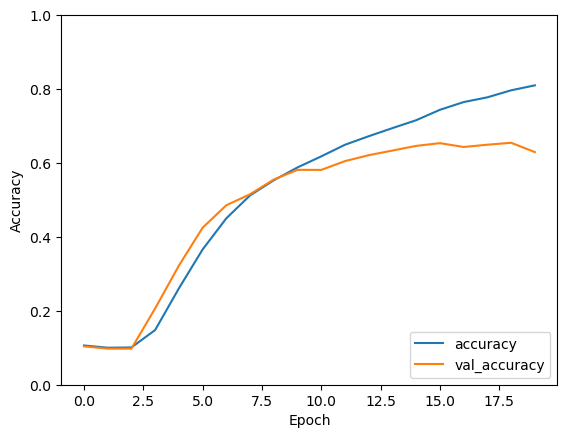

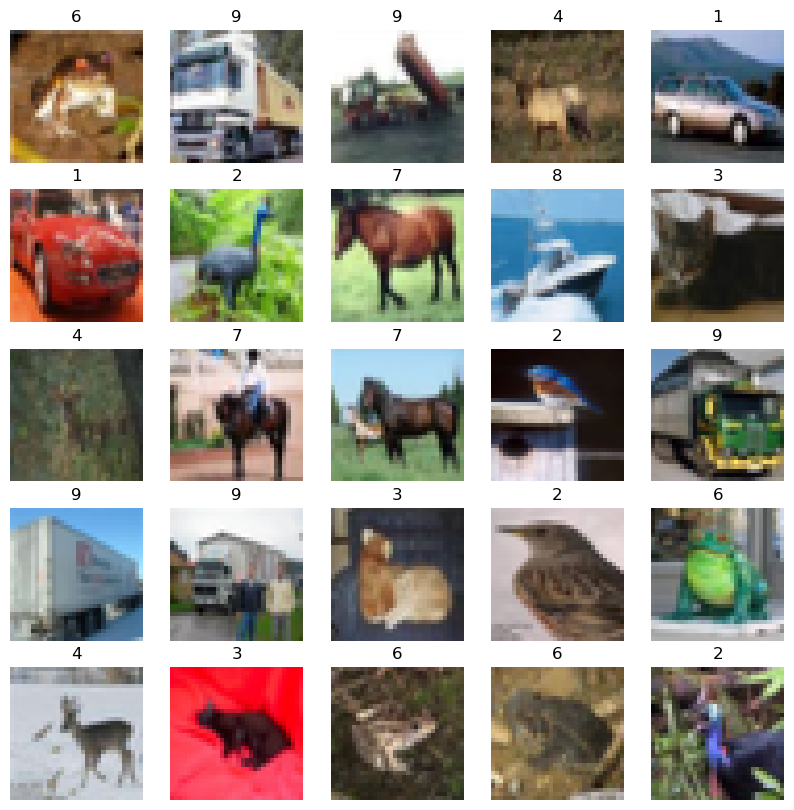

In [2]:
# GoogleNet model
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Layer, concatenate, GlobalAveragePooling2D
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

# Check if GPU is available
print("Num GPUs Available: ", len(tf.config.experimental.list_physical_devices('GPU')))

# Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# Preprocess data
x_train_preprocessed = x_train.astype('float32') / 255.0
x_test_preprocessed = x_test.astype('float32') / 255.0

# Define Inception module layer
class InceptionModule(Layer):
    def __init__(self, filters_1x1, filters_3x3_reduce, filters_3x3, filters_5x5_reduce, filters_5x5, filters_pool, **kwargs):
        super(InceptionModule, self).__init__(**kwargs)
        self.branch1x1 = Conv2D(filters_1x1, (1, 1), padding='same', activation='relu')
        
        self.branch3x3_reduce = Conv2D(filters_3x3_reduce, (1, 1), padding='same', activation='relu')
        self.branch3x3 = Conv2D(filters_3x3, (3, 3), padding='same', activation='relu')
        
        self.branch5x5_reduce = Conv2D(filters_5x5_reduce, (1, 1), padding='same', activation='relu')
        self.branch5x5 = Conv2D(filters_5x5, (5, 5), padding='same', activation='relu')
        
        self.branch_pool = MaxPooling2D((3, 3), strides=(1, 1), padding='same')
        self.branch_pool_conv = Conv2D(filters_pool, (1, 1), padding='same', activation='relu')

    def call(self, inputs):
        branch1x1 = self.branch1x1(inputs)
        
        branch3x3 = self.branch3x3_reduce(inputs)
        branch3x3 = self.branch3x3(branch3x3)
        
        branch5x5 = self.branch5x5_reduce(inputs)
        branch5x5 = self.branch5x5(branch5x5)
        
        branch_pool = self.branch_pool(inputs)
        branch_pool = self.branch_pool_conv(branch_pool)
        
        return concatenate([branch1x1, branch3x3, branch5x5, branch_pool], axis=-1)

# Define GoogleNet (Inception V1) model
def create_googlenet_model():
    model = Sequential()
    model.add(Conv2D(64, (7, 7), activation='relu', strides=(2, 2), padding='same', input_shape=(32, 32, 3)))
    model.add(MaxPooling2D((3, 3), strides=(2, 2), padding='same'))
    model.add(Conv2D(64, (1, 1), activation='relu', padding='same'))
    model.add(Conv2D(192, (3, 3), activation='relu', padding='same'))
    model.add(MaxPooling2D((3, 3), strides=(2, 2), padding='same'))

    # Inception modules
    model.add(InceptionModule(64, 96, 128, 16, 32, 32))  # 3a
    model.add(InceptionModule(128, 128, 192, 32, 96, 64))  # 3b
    model.add(MaxPooling2D((3, 3), strides=(2, 2), padding='same'))

    model.add(InceptionModule(192, 96, 208, 16, 48, 64))  # 4a
    model.add(InceptionModule(160, 112, 224, 24, 64, 64))  # 4b
    model.add(InceptionModule(128, 128, 256, 24, 64, 64))  # 4c
    model.add(InceptionModule(112, 144, 288, 32, 64, 64))  # 4d
    model.add(InceptionModule(256, 160, 320, 32, 128, 128))  # 4e
    model.add(MaxPooling2D((3, 3), strides=(2, 2), padding='same'))

    model.add(InceptionModule(256, 160, 320, 32, 128, 128))  # 5a
    model.add(InceptionModule(384, 192, 384, 48, 128, 128))  # 5b

    # Global average pooling
    model.add(GlobalAveragePooling2D())

    model.add(Dense(10, activation='softmax'))  # Output layer for 10 classes
    return model

# Compile and train model
def compile_and_train_model(model):
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    history = model.fit(x_train_preprocessed, y_train, epochs=20, batch_size=128, validation_split=0.1)
    return history

# Evaluate model
def evaluate_model(model):
    _, accuracy = model.evaluate(x_test_preprocessed, y_test)
    print("Test Accuracy:", accuracy)

# Plot training history
def plot_training_history(history):
    plt.plot(history.history['accuracy'], label='accuracy')
    plt.plot(history.history['val_accuracy'], label='val_accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.ylim([0, 1])
    plt.legend(loc='lower right')
    plt.show()

# Create and train GoogleNet model
print("\nGoogleNet (Inception V1) Model:")
googlenet_model = create_googlenet_model()
history = compile_and_train_model(googlenet_model)
evaluate_model(googlenet_model)

# Plot training history
plot_training_history(history)

# Plot a sample of images along with their labels
plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.imshow(x_train_preprocessed[i])
    plt.title(np.argmax(y_train[i]))
    plt.axis('off')
plt.show()
